###### 実務寄り練習問題

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df_quality = pd.DataFrame(
    [
        ["2026-06", "MELMB", "Lamp-A", "不点灯", 12000, 18, "対応中"],
        ["2026-06", "WSE", "Lamp-B", "ちらつき", 8000, 32, "未対応"],
        ["2026-06", "GSE", "Lamp-C", "外観不良", 15000, 9, "完了"],
        ["2026-07", "MELMB", "Lamp-A", "不点灯", 11000, 25, "対応中"],
        ["2026-07", "WSE", "Lamp-B", "ショート", 9000, 45, "未対応"],
        ["2026-07", "GSE", "Lamp-C", "外観不良", 14000, 7, "完了"],
    ],
    columns=[
        "month",
        "site",
        "product",
        "defect_type",
        "production_qty",
        "defect_qty",
        "status",
    ],
)

df_quality

,month,site,product,defect_type,production_qty,defect_qty,status
0,2026-06,MELMB,Lamp-A,不点灯,12000,18,対応中
1,2026-06,WSE,Lamp-B,ちらつき,8000,32,未対応
2,2026-06,GSE,Lamp-C,外観不良,15000,9,完了
3,2026-07,MELMB,Lamp-A,不点灯,11000,25,対応中
4,2026-07,WSE,Lamp-B,ショート,9000,45,未対応
5,2026-07,GSE,Lamp-C,外観不良,14000,7,完了


In [6]:
df_quality["ppm"] = (
    df_quality["defect_qty"] / df_quality["production_qty"] * 1000000
).round(1)

df_quality

,month,site,product,defect_type,production_qty,defect_qty,status,ppm
0,2026-06,MELMB,Lamp-A,不点灯,12000,18,対応中,1500.0
1,2026-06,WSE,Lamp-B,ちらつき,8000,32,未対応,4000.0
2,2026-06,GSE,Lamp-C,外観不良,15000,9,完了,600.0
3,2026-07,MELMB,Lamp-A,不点灯,11000,25,対応中,2272.7
4,2026-07,WSE,Lamp-B,ショート,9000,45,未対応,5000.0
5,2026-07,GSE,Lamp-C,外観不良,14000,7,完了,500.0


In [7]:
df_quality["risk_level"] = np.where(
    df_quality["ppm"] >= 3000,
    "危険",
    np.where(
        df_quality["ppm"] >= 1000,
        "注意",
        "通常"
    )
)

df_quality


,month,site,product,defect_type,production_qty,defect_qty,status,ppm,risk_level
0,2026-06,MELMB,Lamp-A,不点灯,12000,18,対応中,1500.0,注意
1,2026-06,WSE,Lamp-B,ちらつき,8000,32,未対応,4000.0,危険
2,2026-06,GSE,Lamp-C,外観不良,15000,9,完了,600.0,通常
3,2026-07,MELMB,Lamp-A,不点灯,11000,25,対応中,2272.7,注意
4,2026-07,WSE,Lamp-B,ショート,9000,45,未対応,5000.0,危険
5,2026-07,GSE,Lamp-C,外観不良,14000,7,完了,500.0,通常


In [8]:
df_report = df_quality[
    [
        "month",
        "site",
        "product",
        "defect_type",
        "defect_qty",
        "ppm",
        "risk_level",
        "status",
    ]
]
df_report

,month,site,product,defect_type,defect_qty,ppm,risk_level,status
0,2026-06,MELMB,Lamp-A,不点灯,18,1500.0,注意,対応中
1,2026-06,WSE,Lamp-B,ちらつき,32,4000.0,危険,未対応
2,2026-06,GSE,Lamp-C,外観不良,9,600.0,通常,完了
3,2026-07,MELMB,Lamp-A,不点灯,25,2272.7,注意,対応中
4,2026-07,WSE,Lamp-B,ショート,45,5000.0,危険,未対応
5,2026-07,GSE,Lamp-C,外観不良,7,500.0,通常,完了


In [9]:
df_danger = df_quality[df_quality["risk_level"] == "危険"]
df_danger[
    [
        "month",
        "site",
        "product",
        "defect_type",
        "ppm",
        "status",
    ]
]

df_danger


,month,site,product,defect_type,production_qty,defect_qty,status,ppm,risk_level
1,2026-06,WSE,Lamp-B,ちらつき,8000,32,未対応,4000.0,危険
4,2026-07,WSE,Lamp-B,ショート,9000,45,未対応,5000.0,危険


In [10]:
df_ppm_ranking = df_quality[
    [
        "site",
        "product",
        "defect_type",
        "ppm",
        "risk_level",
    ]
].sort_values("ppm", ascending=False)

df_ppm_ranking

,site,product,defect_type,ppm,risk_level
4,WSE,Lamp-B,ショート,5000.0,危険
1,WSE,Lamp-B,ちらつき,4000.0,危険
3,MELMB,Lamp-A,不点灯,2272.7,注意
0,MELMB,Lamp-A,不点灯,1500.0,注意
2,GSE,Lamp-C,外観不良,600.0,通常
5,GSE,Lamp-C,外観不良,500.0,通常


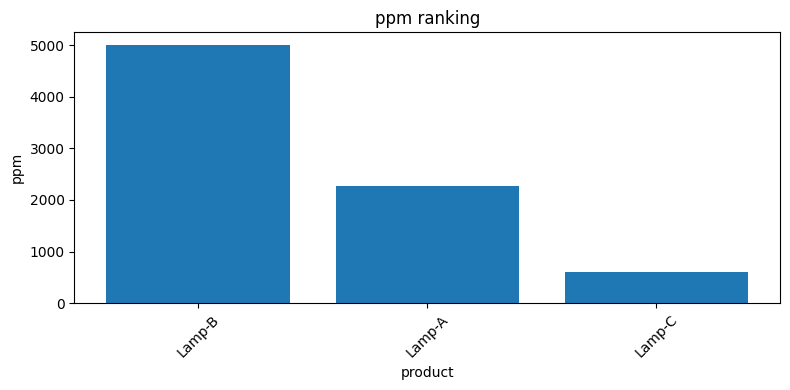

In [19]:
plt.figure(figsize=(8, 4))
plt.bar(df_ppm_ranking["product"], df_ppm_ranking["ppm"])
plt.title("ppm ranking")
plt.xlabel("product")
plt.ylabel("ppm")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()